# 🏦 FinGuard AI — Data Preprocessing

### AI-Powered Financial Fraud Detection & Risk Intelligence Platform

**Notebook:** 03 — Data Preprocessing  
**Project:** FinGuard AI  
**Dataset:** Credit Card Transactions

#### Objective
Prepare the transaction dataset for machine-learning models through validation, duplicate handling, train-test splitting, scaling, class-imbalance handling, and processed-dataset generation.

> **Important:** The original raw dataset remains unchanged.

#### 1. Preprocessing Strategy

The workflow is leakage-safe:

1. Load and validate the raw dataset.
2. Remove exact duplicate rows.
3. Separate features and target.
4. Perform a stratified 80/20 train-test split.
5. Fit the scaler on training data only.
6. Transform the test set using the training scaler.
7. Apply SMOTE only to the training set.
8. Save processed datasets and preprocessing artifacts.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

print("FinGuard AI — Data Preprocessing")
print("=" * 70)
print(f"Python Version : {sys.version.split()[0]}")
print(f"NumPy Version  : {np.__version__}")
print(f"Pandas Version : {pd.__version__}")
print("=" * 70)

FinGuard AI — Data Preprocessing
Python Version : 3.11.15
NumPy Version  : 2.4.6
Pandas Version : 3.0.5


#### 2. Project Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "Dataset"
RAW_DATA_DIR = DATASET_DIR / "Raw"
PROCESSED_DATA_DIR = DATASET_DIR / "Processed"
SAMPLE_DATA_DIR = DATASET_DIR / "Sample"

MODELS_DIR = PROJECT_ROOT / "Models"
REPORTS_DIR = PROJECT_ROOT / "Reports"
PREPROCESSING_REPORT_DIR = REPORTS_DIR / "Preprocessing"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DATA_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSING_REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = RAW_DATA_DIR / "creditcard.csv"

print("Project Paths")
print("=" * 70)
print(f"Project Root      : {PROJECT_ROOT}")
print(f"Raw Dataset       : {RAW_DATA_PATH}")
print(f"Processed Dataset : {PROCESSED_DATA_DIR}")
print(f"Models            : {MODELS_DIR}")
print(f"Reports           : {PREPROCESSING_REPORT_DIR}")

Project Paths
Project Root      : C:\Users\viqua\Desktop\FinGuard AI
Raw Dataset       : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Raw\creditcard.csv
Processed Dataset : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed
Models            : C:\Users\viqua\Desktop\FinGuard AI\Models
Reports           : C:\Users\viqua\Desktop\FinGuard AI\Reports\Preprocessing


#### 3. Load Raw Dataset

In [3]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Raw dataset not found: {RAW_DATA_PATH}")

df = pd.read_csv(RAW_DATA_PATH)

print("✓ Raw dataset loaded successfully")
print("=" * 70)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("=" * 70)

display(df.head())

✓ Raw dataset loaded successfully
Rows    : 284,807
Columns : 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### 4. Dataset Structure Validation

In [4]:
EXPECTED_ROWS = 284_807
EXPECTED_COLUMNS = 31

print("Dataset Structure Validation")
print("=" * 70)
print(f"Actual Rows      : {df.shape[0]:,}")
print(f"Expected Rows    : {EXPECTED_ROWS:,}")
print(f"Actual Columns   : {df.shape[1]}")
print(f"Expected Columns : {EXPECTED_COLUMNS}")

assert "Class" in df.columns
assert df.shape[1] == EXPECTED_COLUMNS

print("✓ Dataset structure validation passed")

Dataset Structure Validation
Actual Rows      : 284,807
Expected Rows    : 284,807
Actual Columns   : 31
Expected Columns : 31
✓ Dataset structure validation passed


#### 5. Column and Data-Type Inspection

In [5]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isna().sum().values,
    "Unique_Values": df.nunique().values
})

display(column_summary)

,Column,Data_Type,Missing_Values,Unique_Values
0,Time,float64,0,124592
1,V1,float64,0,275663
2,V2,float64,0,275663
3,V3,float64,0,275663
4,V4,float64,0,275663
5,V5,float64,0,275663
6,V6,float64,0,275663
7,V7,float64,0,275663
8,V8,float64,0,275663
9,V9,float64,0,275663


#### 6. Missing and Infinite Value Validation

In [6]:
missing_values = int(df.isna().sum().sum())
numeric_df = df.select_dtypes(include=[np.number])
infinite_values = int(np.isinf(numeric_df.to_numpy()).sum())

print("Data Quality Validation")
print("=" * 70)
print(f"Missing Values  : {missing_values:,}")
print(f"Infinite Values : {infinite_values:,}")

assert missing_values == 0
assert infinite_values == 0

print("✓ No missing or infinite values detected")

Data Quality Validation
Missing Values  : 0
Infinite Values : 0
✓ No missing or infinite values detected


#### 7. Duplicate Transaction Analysis

In [7]:
duplicate_count = int(df.duplicated().sum())

print("Duplicate Transaction Analysis")
print("=" * 70)
print(f"Duplicate Rows : {duplicate_count:,}")

Duplicate Transaction Analysis
Duplicate Rows : 1,081


#### 8. Remove Exact Duplicate Rows

In [8]:
rows_before = len(df)

df_clean = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df_clean)
duplicates_removed = rows_before - rows_after

print("Duplicate Handling")
print("=" * 70)
print(f"Rows Before : {rows_before:,}")
print(f"Rows After  : {rows_after:,}")
print(f"Removed     : {duplicates_removed:,}")
print("✓ Clean working dataset created")

Duplicate Handling
Rows Before : 284,807
Rows After  : 283,726
Removed     : 1,081
✓ Clean working dataset created


#### 9. Validate Target Variable

In [9]:
target_counts = df_clean["Class"].value_counts().sort_index()

print("Target Variable Validation")
print("=" * 70)
display(target_counts.rename("Transaction_Count").to_frame())

assert set(target_counts.index).issubset({0, 1})

print("Target Mapping:")
print("0 → Legitimate Transaction")
print("1 → Fraudulent Transaction")

Target Variable Validation


,Transaction_Count
Class,
0,283253
1,473


Target Mapping:
0 → Legitimate Transaction
1 → Fraudulent Transaction


#### 10. Separate Features and Target

In [10]:
X = df_clean.drop(columns=["Class"]).copy()
y = df_clean["Class"].copy()

print("Feature / Target Separation")
print("=" * 70)
print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")
print(f"Feature Count  : {X.shape[1]}")

Feature / Target Separation
Features Shape : (283726, 30)
Target Shape   : (283726,)
Feature Count  : 30


#### 11. Stratified Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split")
print("=" * 70)
print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")
print(f"Training Fraud   : {int(y_train.sum()):,}")
print(f"Testing Fraud    : {int(y_test.sum()):,}")
print("✓ Stratified 80/20 split completed")

Train-Test Split
Training Samples : 226,980
Testing Samples  : 56,746
Training Fraud   : 378
Testing Fraud    : 95
✓ Stratified 80/20 split completed


#### 12. Feature Scaling Strategy

The `Time` and `Amount` columns have different numeric scales from the PCA-transformed `V1`–`V28` features.

Therefore:

- `Time` → StandardScaler
- `Amount` → StandardScaler
- `V1`–`V28` → retained as provided
- `Class` → target and never scaled

The scaler is fitted only on training data.

In [12]:
SCALE_COLUMNS = ["Time", "Amount"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[SCALE_COLUMNS] = scaler.fit_transform(X_train[SCALE_COLUMNS])
X_test_scaled[SCALE_COLUMNS] = scaler.transform(X_test[SCALE_COLUMNS])

print("Feature Scaling")
print("=" * 70)
print(f"Scaled Columns : {SCALE_COLUMNS}")
print("✓ Scaler fitted on training data only")
print("✓ Test data transformed using the training scaler")

Feature Scaling
Scaled Columns : ['Time', 'Amount']
✓ Scaler fitted on training data only
✓ Test data transformed using the training scaler


#### 13. Verify Scaling

In [13]:
scaling_check = pd.DataFrame({
    "Feature": SCALE_COLUMNS,
    "Train_Mean": [X_train_scaled[c].mean() for c in SCALE_COLUMNS],
    "Train_Std": [X_train_scaled[c].std() for c in SCALE_COLUMNS],
    "Test_Mean": [X_test_scaled[c].mean() for c in SCALE_COLUMNS],
    "Test_Std": [X_test_scaled[c].std() for c in SCALE_COLUMNS]
})

display(scaling_check)

,Feature,Train_Mean,Train_Std,Test_Mean,Test_Std
0,Time,-1.522636e-16,1.000002,-0.009386,0.999221
1,Amount,7.487965e-17,1.000002,0.001741,1.091001


#### 14. Class Imbalance Analysis

,Class,Count,Percentage
0,0,226602,99.833466
1,1,378,0.166534


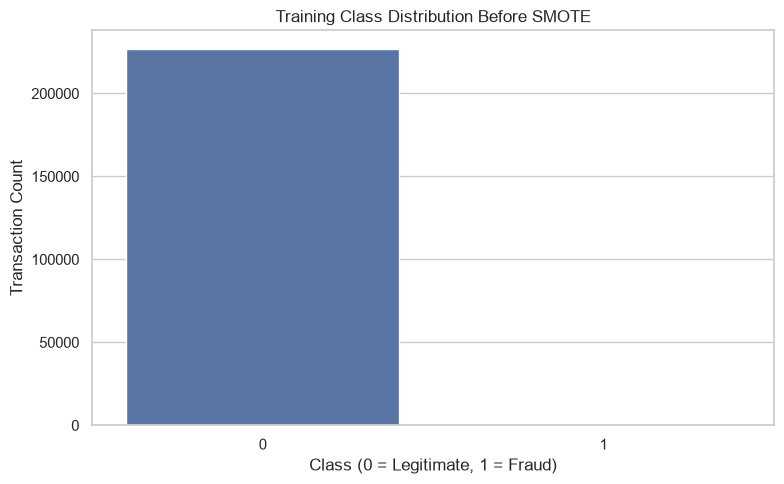

In [14]:
before_smote = pd.DataFrame({
    "Class": y_train.value_counts().sort_index().index,
    "Count": y_train.value_counts().sort_index().values
})

before_smote["Percentage"] = (
    before_smote["Count"] / before_smote["Count"].sum() * 100
)

display(before_smote)

plt.figure(figsize=(8, 5))
sns.barplot(data=before_smote, x="Class", y="Count")
plt.title("Training Class Distribution Before SMOTE")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

#### 15. Apply SMOTE to Training Data Only

SMOTE is used to reduce the severe fraud-class imbalance.

**Important:** SMOTE is never applied to the test set.

The test set remains untouched so that final model evaluation reflects the real class distribution.

In [15]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("SMOTE Resampling")
print("=" * 70)
print(f"Original Training Shape : {X_train_scaled.shape}")
print(f"Balanced Training Shape : {X_train_balanced.shape}")
print(f"Original Fraud Count    : {int(y_train.sum()):,}")
print(f"Balanced Fraud Count    : {int(y_train_balanced.sum()):,}")
print("✓ SMOTE applied only to training data")

SMOTE Resampling
Original Training Shape : (226980, 30)
Balanced Training Shape : (453204, 30)
Original Fraud Count    : 378
Balanced Fraud Count    : 226,602
✓ SMOTE applied only to training data


#### 16. Verify Balanced Training Data

,Class,Count,Percentage
0,0,226602,50.0
1,1,226602,50.0


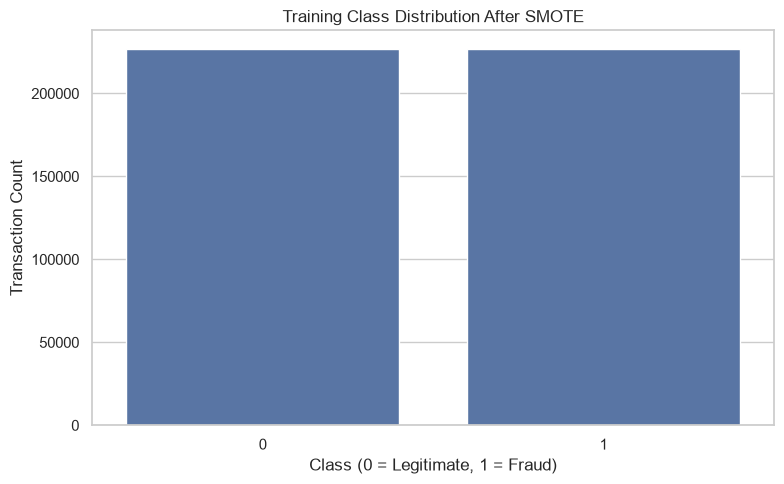

In [16]:
balanced_distribution = pd.DataFrame({
    "Class": y_train_balanced.value_counts().sort_index().index,
    "Count": y_train_balanced.value_counts().sort_index().values
})

balanced_distribution["Percentage"] = (
    balanced_distribution["Count"] /
    balanced_distribution["Count"].sum() * 100
)

display(balanced_distribution)

plt.figure(figsize=(8, 5))
sns.barplot(data=balanced_distribution, x="Class", y="Count")
plt.title("Training Class Distribution After SMOTE")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

#### 17. Create Processed DataFrames

In [17]:
train_original_df = X_train_scaled.copy()
train_original_df["Class"] = y_train.to_numpy()

train_balanced_df = X_train_balanced.copy()
train_balanced_df["Class"] = y_train_balanced.to_numpy()

test_processed_df = X_test_scaled.copy()
test_processed_df["Class"] = y_test.to_numpy()

print("Processed DataFrames")
print("=" * 70)
print(f"Original Train   : {train_original_df.shape}")
print(f"Balanced Train   : {train_balanced_df.shape}")
print(f"Test Set         : {test_processed_df.shape}")

Processed DataFrames
Original Train   : (226980, 31)
Balanced Train   : (453204, 31)
Test Set         : (56746, 31)


#### 18. Save Processed Datasets

In [18]:
TRAIN_ORIGINAL_PATH = PROCESSED_DATA_DIR / "train_processed.csv"
TRAIN_BALANCED_PATH = PROCESSED_DATA_DIR / "train_balanced_smote.csv"
TEST_PROCESSED_PATH = PROCESSED_DATA_DIR / "test_processed.csv"

train_original_df.to_csv(TRAIN_ORIGINAL_PATH, index=False)
train_balanced_df.to_csv(TRAIN_BALANCED_PATH, index=False)
test_processed_df.to_csv(TEST_PROCESSED_PATH, index=False)

print("Processed Dataset Files")
print("=" * 70)
print(f"✓ {TRAIN_ORIGINAL_PATH.name}")
print(f"✓ {TRAIN_BALANCED_PATH.name}")
print(f"✓ {TEST_PROCESSED_PATH.name}")

Processed Dataset Files
✓ train_processed.csv
✓ train_balanced_smote.csv
✓ test_processed.csv


#### 19. Save Preprocessing Artifacts

In [19]:
SCALER_PATH = MODELS_DIR / "standard_scaler.joblib"
METADATA_PATH = MODELS_DIR / "preprocessing_metadata.joblib"

joblib.dump(scaler, SCALER_PATH)

preprocessing_metadata = {
    "scale_columns": SCALE_COLUMNS,
    "target_column": "Class",
    "random_state": 42,
    "test_size": 0.20,
    "duplicate_rows_removed": duplicates_removed,
    "smote_applied": True,
    "dataset_file": RAW_DATA_PATH.name
}

joblib.dump(preprocessing_metadata, METADATA_PATH)

print("Preprocessing Artifacts")
print("=" * 70)
print(f"✓ Scaler   : {SCALER_PATH.name}")
print(f"✓ Metadata : {METADATA_PATH.name}")

Preprocessing Artifacts
✓ Scaler   : standard_scaler.joblib
✓ Metadata : preprocessing_metadata.joblib


#### 20. Final Data Quality Validation

In [20]:
validation_results = {
    "Train Original Missing": int(train_original_df.isna().sum().sum()),
    "Train Balanced Missing": int(train_balanced_df.isna().sum().sum()),
    "Test Missing": int(test_processed_df.isna().sum().sum()),
    "Train Original Infinite": int(np.isinf(train_original_df.select_dtypes(include=np.number).to_numpy()).sum()),
    "Train Balanced Infinite": int(np.isinf(train_balanced_df.select_dtypes(include=np.number).to_numpy()).sum()),
    "Test Infinite": int(np.isinf(test_processed_df.select_dtypes(include=np.number).to_numpy()).sum())
}

validation_df = pd.DataFrame(
    list(validation_results.items()),
    columns=["Validation", "Count"]
)

display(validation_df)

assert all(value == 0 for value in validation_results.values())

print("✓ Final data-quality validation passed")

,Validation,Count
0,Train Original Missing,0
1,Train Balanced Missing,0
2,Test Missing,0
3,Train Original Infinite,0
4,Train Balanced Infinite,0
5,Test Infinite,0


✓ Final data-quality validation passed


#### 21. Processed Dataset Preview

In [21]:
print("Balanced Training Dataset Preview")
print("=" * 70)
display(train_balanced_df.head())

print("Test Dataset Preview")
print("=" * 70)
display(test_processed_df.head())

Balanced Training Dataset Preview


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.045499,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,1.567867,-0.235685,-0.705588,0.363543,-0.313460,0.285037,-0.577606,0.381516,-0.180758,-0.318110,-0.323810,-0.149574,-0.049333,0.278442,0.684735,-0.219028,-0.159167,0.037920,-0.049932,-0.229434,0
1,-0.298690,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,-0.482635,1.437124,1.762389,1.254318,0.862657,-0.266203,0.393813,-0.265345,-0.343555,0.392417,-0.067580,-0.238898,-0.946773,0.323904,0.515632,-0.713000,-0.266503,-0.017794,0.051058,-0.331197,0
2,0.678397,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,-0.497766,1.532977,1.039161,0.475691,-0.689465,0.964112,-0.277525,0.793328,-0.156680,-0.994654,-0.210474,0.293609,1.095842,-0.044874,-1.689517,0.106098,0.007758,0.045164,-0.053068,-0.298809,0
3,-0.074929,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,1.146705,1.337319,-1.775051,2.178843,1.239627,-2.037103,1.344143,-0.475182,0.824830,-1.693484,-0.228032,0.138869,0.700422,0.174064,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,-0.289247,0
4,-1.376728,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,1.492821,1.737807,0.014396,0.329795,-0.044638,0.473131,-0.659717,0.787525,-0.641416,-0.591751,-0.361686,-0.340972,-0.636442,0.252758,-0.344160,-0.064282,-0.439622,0.062524,0.013095,-0.261985,0


Test Dataset Preview


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
86249,-0.707761,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,-0.273054,-1.252728,0.465079,0.400502,-0.292842,-0.101774,-0.399836,0.034336,-0.783550,0.141345,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,-0.312846,0
250634,1.273872,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,-0.506595,-1.394841,-0.092472,0.021634,0.730797,0.496343,-0.199594,-0.434390,0.348660,0.162524,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,-0.351745,0
20163,-1.348111,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,3.071219,0.768574,0.202065,1.349180,-0.950567,0.922046,0.366995,-1.215489,0.598610,1.425968,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,0.011771,0
68688,-0.878056,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,0.871966,0.906599,0.386404,0.101522,0.275543,0.703471,-1.004960,-0.425904,1.774010,-1.399609,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,0.568071,0
191151,0.727104,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,-0.527043,0.985105,1.036503,0.417644,-1.641894,-1.123470,0.316818,0.891983,0.610567,0.215798,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,-0.353901,0


#### 22. Preprocessing Summary

In [22]:
summary = pd.DataFrame({
    "Metric": [
        "Original Rows",
        "Rows After Duplicate Removal",
        "Duplicate Rows Removed",
        "Original Columns",
        "Training Samples",
        "Testing Samples",
        "Balanced Training Samples",
        "Training Fraud Cases Before SMOTE",
        "Training Fraud Cases After SMOTE",
        "Missing Values",
        "Infinite Values"
    ],
    "Value": [
        len(df),
        len(df_clean),
        duplicates_removed,
        df.shape[1],
        len(X_train_scaled),
        len(X_test_scaled),
        len(X_train_balanced),
        int(y_train.sum()),
        int(y_train_balanced.sum()),
        missing_values,
        infinite_values
    ]
})

display(summary)

,Metric,Value
0,Original Rows,284807
1,Rows After Duplicate Removal,283726
2,Duplicate Rows Removed,1081
3,Original Columns,31
4,Training Samples,226980
5,Testing Samples,56746
6,Balanced Training Samples,453204
7,Training Fraud Cases Before SMOTE,378
8,Training Fraud Cases After SMOTE,226602
9,Missing Values,0


#### 23. Generated Files

In [23]:
generated_files = [
    TRAIN_ORIGINAL_PATH,
    TRAIN_BALANCED_PATH,
    TEST_PROCESSED_PATH,
    SCALER_PATH,
    METADATA_PATH
]

print("Generated Preprocessing Artifacts")
print("=" * 70)

for file_path in generated_files:
    status = "✓ EXISTS" if file_path.exists() else "✗ MISSING"
    print(f"{status:<12} {file_path}")

Generated Preprocessing Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\train_processed.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\train_balanced_smote.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\test_processed.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\standard_scaler.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\preprocessing_metadata.joblib


#### 24. Modeling Note

For downstream modeling:

- Use `train_balanced_smote.csv` when balanced training data is required.
- Use `test_processed.csv` for final evaluation.
- Never apply SMOTE to the test set.
- Never fit the scaler on the test set.
- Keep `creditcard.csv` unchanged.
- Evaluate fraud detection using Precision, Recall, F1-score, PR-AUC, ROC-AUC, False Positive Rate and False Negative Rate rather than accuracy alone.

#### 25. Next Stage

#### Notebook 04 — Feature Engineering

The next notebook will develop fraud-specific behavioral features and model-ready representations.

Planned work:

- Transaction amount features
- Temporal features
- Transaction frequency features
- Velocity-style features
- Risk-oriented behavioral features
- Feature selection
- Model-ready feature generation

**The raw dataset will remain unchanged.**

In [24]:
print("=" * 75)
print("FIN GUARD AI — PREPROCESSING SUMMARY")
print("=" * 75)
print(f"✓ Original Rows          : {len(df):,}")
print(f"✓ Duplicate Rows Removed : {duplicates_removed:,}")
print(f"✓ Clean Rows             : {len(df_clean):,}")
print(f"✓ Features               : {X.shape[1]}")
print(f"✓ Training Samples       : {len(X_train_scaled):,}")
print(f"✓ Testing Samples        : {len(X_test_scaled):,}")
print(f"✓ Balanced Train Samples : {len(X_train_balanced):,}")
print("✓ SMOTE                  : Applied to training data only")
print("✓ Scaler                 : Saved")
print("✓ Processed Datasets     : Saved")
print("=" * 75)
print("✓ NOTEBOOK 03 DATA PREPROCESSING COMPLETED")
print("=" * 75)

FIN GUARD AI — PREPROCESSING SUMMARY
✓ Original Rows          : 284,807
✓ Duplicate Rows Removed : 1,081
✓ Clean Rows             : 283,726
✓ Features               : 30
✓ Training Samples       : 226,980
✓ Testing Samples        : 56,746
✓ Balanced Train Samples : 453,204
✓ SMOTE                  : Applied to training data only
✓ Scaler                 : Saved
✓ Processed Datasets     : Saved
✓ NOTEBOOK 03 DATA PREPROCESSING COMPLETED
